In [ ]:
# Step 0: Install dependencies
!pip install -q transformers datasets torch evaluate accelerate scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.5 MB/s eta 0:00:00


In [ ]:
import os
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import Dataset
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import ( accuracy_score, precision_recall_fscore_support, classification_report)

import torch
from transformers import ( AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback,DataCollatorWithPadding,)

pd.set_option("display.max_rows", 100)

In [ ]:
# Loading Original Split + Pseudo-Labels

In [ ]:
# 1) Loading the original frozen split, pseudo-label files, and saved baseline results
from google.colab import drive
drive.mount('/content/drive')

# Setting the main Drive directories
DRIVE_DIR = "/content/drive/MyDrive/apt_extraction"
SPLIT_DIR = os.path.join(DRIVE_DIR, "exp_split")
BASELINE_SCORES_DIR = os.path.join(DRIVE_DIR, "baseline_scores")

# Creating the split directory if it does not exist
os.makedirs(SPLIT_DIR, exist_ok=True)

# Defining the paths to the pseudo-label files
PSEUDO_FILES = {
    "attack": os.path.join(DRIVE_DIR, "verified_pseudo_labels.json"),
    "cosine": os.path.join(DRIVE_DIR, "verified_pseudo_labels_cosine.json"),
}

# Loading the original frozen train, validation, and test splits
train_df = pd.read_json(os.path.join(SPLIT_DIR, "train_df.json"))
valid_df = pd.read_json(os.path.join(SPLIT_DIR, "valid_df.json"))
test_df = pd.read_json(os.path.join(SPLIT_DIR, "test_df.json"))

# Loading the relation label classes
with open(os.path.join(SPLIT_DIR, "label_classes.json"), "r") as f:
    label_classes = json.load(f)

# Creating mappings between relation labels and numerical indices
label_to_idx = {label: i for i, label in enumerate(label_classes)}
idx_to_label = {i: label for label, i in label_to_idx.items()}

# Printing the loaded split sizes and label classes
print(f"Loaded split: train={len(train_df)} valid={len(valid_df)} test={len(test_df)}")
print(f"Label classes: {len(label_classes)}")
print(label_classes)

# Loading the available pseudo-label datasets from Drive
pseudo_sets = {}
for name, path in PSEUDO_FILES.items():
    if os.path.exists(path):
        df = pd.read_json(path)
        pseudo_sets[name] = df
        print(f"Loaded {name}: {len(df)} rows")
    else:
        print(f"Missing {name}: {path}")

# Stoping if no pseudo-label files are available
if not pseudo_sets:
    raise FileNotFoundError("No pseudo-label files were found. Upload them to Drive first.")

# Defining the path to the previously saved baseline test results
baseline_results_path = os.path.join(BASELINE_SCORES_DIR, "baseline_results.json")

# Checking that the baseline results file exists
if not os.path.exists(baseline_results_path):
    raise FileNotFoundError( f"Could not find saved baseline results at {baseline_results_path}. "
        "Run the baseline notebook first so its results are saved to Drive."
    )

# Loading the previously saved baseline results
with open(baseline_results_path, "r") as f:
    baseline_results = json.load(f)

# Printing the saved baseline results without retraining the baseline models
print("\nLoaded baseline (already trained) test results — these will NOT be retrained:")
print(json.dumps(baseline_results, indent=2))

Mounted at /content/drive
Loaded split: train=766 valid=163 test=166
Label classes: 25
['attributed-to', 'authored-by', 'based-on', 'beacons-to', 'communicates-with', 'compromises', 'consists-of', 'controls', 'delivers', 'downloads', 'drops', 'duplicate-of', 'exfiltrates-to', 'exploits', 'has', 'hosts', 'impersonates', 'indicates', 'located-at', 'originates-from', 'owns', 'related-to', 'targets', 'uses', 'variant-of']
Loaded attack: 2179 rows
Loaded cosine: 2112 rows

Loaded baseline (already trained) test results — these will NOT be retrained:
{
  "BERT": {
    "accuracy": 0.6626506024096386,
    "macro_f1": 0.4759592883837843,
    "weighted_f1": 0.642527514123239,
    "macro_precision": 0.48794130472701897,
    "macro_recall": 0.500950252387034
  },
  "SecureBERT": {
    "accuracy": 0.6987951807228916,
    "macro_f1": 0.5499066461913857,
    "weighted_f1": 0.6857528158838163,
    "macro_precision": 0.5778927987345837,
    "macro_recall": 0.5805740176019322
  }
}


In [ ]:
# Schema Cleaning

In [ ]:
# Cleaning each pseudo-label set to match the original labelled dataset schema
def clean_pseudo_df(df, label_to_idx):
    df = df.copy()
    # Checking that all required columns are present
    required_cols = ["marked_text", "head_type", "tail_type", "relation"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column '{col}' in pseudo-label data.")

    # Keeping required columns and remove rows with missing values
    df = df[required_cols].dropna().copy()
    # Keeping only relations that exist in the original label set
    df = df[df["relation"].isin(label_to_idx)].copy()
    # Converting relation labels to numerical class indices
    df["label"] = df["relation"].map(label_to_idx)

    # Reset the DataFrame index
    return df.reset_index(drop=True)
# Applying schema cleaning to each pseudo-label dataset
for name, df in list(pseudo_sets.items()):
    pseudo_sets[name] = clean_pseudo_df(df, label_to_idx)
    print(f"{name}: kept {len(pseudo_sets[name])} rows after schema filtering")

attack: kept 2179 rows after schema filtering
cosine: kept 2112 rows after schema filtering


In [ ]:
# Exploratory Analysis & Plots


=== attack ===
Rows: 2179
Unique relations: 24
Head types:
head_type
threat-actor      866
malware           485
tools             212
FILEPATH          180
Infrastucture     105
attack-pattern     76
campaign           59
identity           56
SOFTWARE           41
IPV4               24
url                21
EMAIL              18
vulnerability      15
hash               12
REGISTRYKEY         8
location            1
Tail types:
tail_type
identity          417
tools             264
Infrastucture     254
malware           225
attack-pattern    197
SOFTWARE          181
FILEPATH          179
threat-actor       97
location           94
vulnerability      88
url                57
hash               32
EMAIL              24
campaign           22
IPV4               17
REGISTRYKEY        17
TIME               14

=== cosine ===
Rows: 2112
Unique relations: 24
Head types:
head_type
threat-actor      830
malware           468
tools             206
FILEPATH          180
Infrastucture     103
at

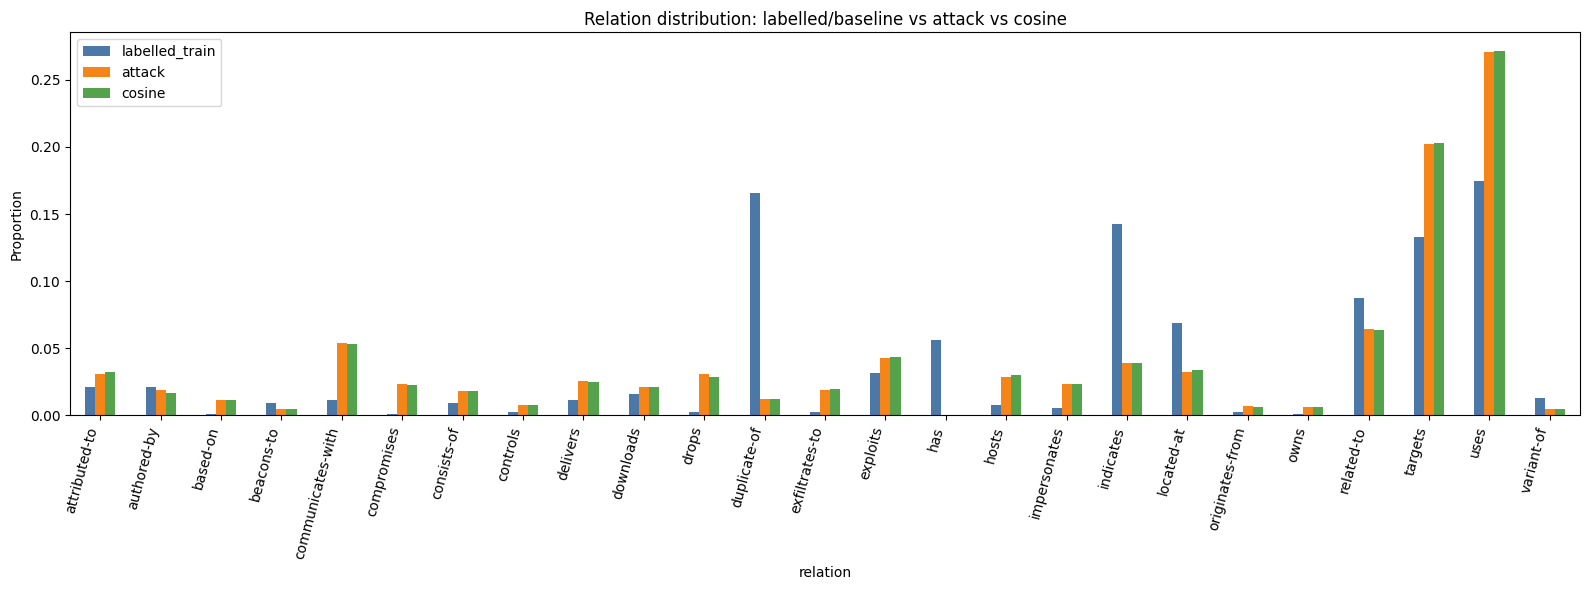


Entity type distribution comparison (proportions, head+tail combined) — labelled vs attack vs cosine:
                labelled_train  attack  cosine
EMAIL                    0.000   0.010   0.010
FILEPATH                 0.085   0.082   0.084
IPV4                     0.004   0.009   0.009
Infrastucture            0.012   0.082   0.083
REGISTRYKEY              0.000   0.006   0.006
SOFTWARE                 0.052   0.051   0.052
TIME                     0.001   0.003   0.003
URL                      0.005   0.000   0.000
attack-pattern           0.078   0.063   0.063
campaign                 0.025   0.019   0.019
hash                     0.070   0.010   0.010
identity                 0.072   0.109   0.109
location                 0.065   0.022   0.022
malware                  0.276   0.163   0.159
threat-actor             0.145   0.221   0.218
tools                    0.035   0.109   0.109
url                      0.012   0.018   0.018
vulnerability            0.065   0.024   0.024


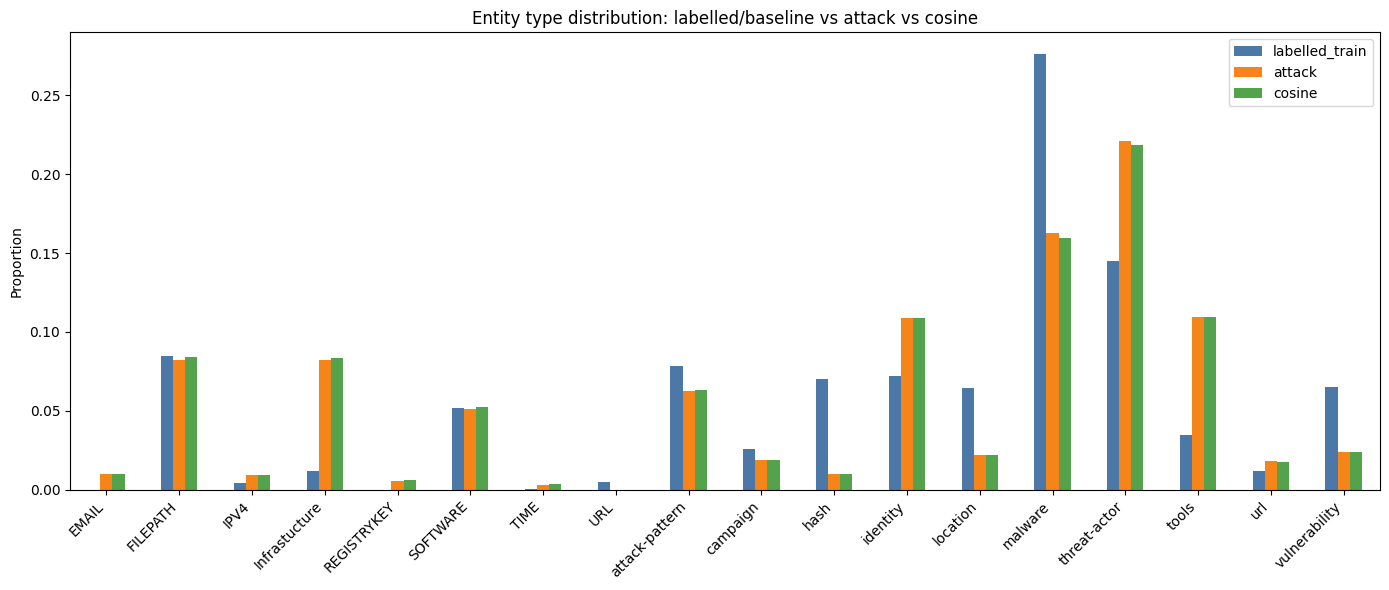


attack: unseen relation labels relative to original training split = []

cosine: unseen relation labels relative to original training split = []


In [ ]:
# Performing basic analysis of the pseudo-label sets and labelled baseline training data
for name, df in pseudo_sets.items():
    print(f"\n=== {name} ===")
    print(f"Rows: {len(df)}")
    print(f"Unique relations: {df['relation'].nunique()}")
    print(f"Head types:\n{df['head_type'].value_counts().to_string()}")
    print(f"Tail types:\n{df['tail_type'].value_counts().to_string()}")

# Printing statistics for the original labelled training data
print("\n=== labelled (baseline train) ===")
print(f"Rows: {len(train_df)}")
print(f"Unique relations: {train_df['relation'].nunique()}")
print(f"Head types:\n{train_df['head_type'].value_counts().to_string()}")
print(f"Tail types:\n{train_df['tail_type'].value_counts().to_string()}")

# Comparing relation distributions across the three datasets
labelled_rel = train_df["relation"].value_counts(normalize=True)
attack_rel = pseudo_sets["attack"]["relation"].value_counts(normalize=True)
cosine_rel = pseudo_sets["cosine"]["relation"].value_counts(normalize=True)

# Combining the relation distributions into one DataFrame
relation_compare = pd.DataFrame({ "labelled_train": labelled_rel, "attack": attack_rel, "cosine": cosine_rel,}).fillna(0.0)

# Printingting the relation distribution comparison
print("\nRelation distribution comparison (proportions) — labelled vs attack vs cosine:")
print(relation_compare.round(3).to_string())

# Plot the relation distributions for comparison
relation_compare.plot( kind="bar",figsize=(16, 6), color=["#4C78A8", "#F58518", "#54A24B"])
plt.title("Relation distribution: labelled/baseline vs attack vs cosine")
plt.ylabel("Proportion")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()


# Comparing entity type distributions across the three datasets(head_type + tail_type combined)
# Calculating the combined distribution of head and tail entity types
def entity_type_dist(df):
    return pd.concat( [df["head_type"], df["tail_type"]], ignore_index=True).value_counts(normalize=True)

# Calculating entity type distributions for each dataset
labelled_entity = entity_type_dist(train_df)
attack_entity = entity_type_dist(pseudo_sets["attack"])
cosine_entity = entity_type_dist(pseudo_sets["cosine"])

# Combining the entity distributions into one DataFrame
entity_compare = pd.DataFrame({ "labelled_train": labelled_entity, "attack": attack_entity, "cosine": cosine_entity,}).fillna(0.0)

# Printing the entity type distribution comparison
print("\nEntity type distribution comparison (proportions, head+tail combined) — labelled vs attack vs cosine:")
print(entity_compare.round(3).to_string())

# Plotting the entity type distributions for comparison
entity_compare.plot( kind="bar", figsize=(14, 6), color=["#4C78A8", "#F58518", "#54A24B"])
plt.title("Entity type distribution: labelled/baseline vs attack vs cosine")
plt.ylabel("Proportion")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Checking for relation labels that are not present in the original training data
for name, df in pseudo_sets.items():
    unseen = sorted(set(df["relation"]) - set(train_df["relation"]))
    print(f"\n{name}: unseen relation labels relative to original training split = {unseen}")

In [ ]:
# Building hybrid training sets by combining the original labelled data with pseudo-labels
# The baseline model is not retrained because its saved results are reused
candidate_train_sets = {}

# Creating one hybrid training set for each pseudo-labeling method
for name, pseudo_df in pseudo_sets.items():
    # Combine the original labelled data with the selected pseudo-labels
    merged = pd.concat(
        [  train_df[["marked_text", "head_type", "tail_type", "relation", "label"]],
            pseudo_df[["marked_text", "head_type", "tail_type", "relation", "label"]],
        ], ignore_index=True
    )

    # Storing the combined training set
    candidate_train_sets[name] = merged

    # Printing the size of the resulting hybrid dataset
    print( f"{name}: merged train size = {len(merged)}  "
        f"(labelled {len(train_df)} + pseudo {len(pseudo_df)})")

# Printing the hybrid training methods that will be trained
print(f"\nHybrid candidates to train: {list(candidate_train_sets.keys())}")
print("Baseline model will NOT be retrained here.")

attack: merged train size = 2945  (labelled 766 + pseudo 2179)
cosine: merged train size = 2878  (labelled 766 + pseudo 2112)

Hybrid candidates to train: ['attack', 'cosine']
Baseline model will NOT be retrained here.


In [ ]:
# Defining the models, evaluation metrics, dataset preparation and training functions
MODELS = {
    "BERT": "bert-base-uncased",
    "SecureBERT": "ehsanaghaei/SecureBERT",
}

# Setting the maximum input sequence length
MAX_LENGTH = 160


# Calculating accuracy, macro, and weighted evaluation metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)

    return {
        "accuracy": acc,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_p,
        "weighted_recall": weighted_r,
        "weighted_f1": weighted_f1,
    }


# Converting the pandas DataFrame into a tokenized Hugging Face dataset
def make_hf_dataset(df, tokenizer):
    ds = Dataset.from_pandas(df[["marked_text", "label"]])
    ds = ds.map(lambda batch: tokenizer(batch["marked_text"], truncation=True, max_length=MAX_LENGTH), batched=True)
    ds = ds.rename_column("label", "labels")
    return ds.remove_columns(["marked_text"])


# Training and evaluate a model on a selected hybrid training dataset
def train_and_evaluate(model_key, model_path, candidate_name, train_data, eval_data):
    print(f"\n{'=' * 60}")
    print(f"Training {model_key} on '{candidate_name}'")
    print(f"{'=' * 60}")

    # Loading the tokenizer and add entity marker tokens
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    tokenizer.add_special_tokens({"additional_special_tokens": ["[E1]", "[/E1]", "[E2]", "[/E2]"]})

    # Preparing the training and evaluation datasets
    train_ds = make_hf_dataset(train_data, tokenizer)
    eval_ds = make_hf_dataset(eval_data, tokenizer)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Loading the pre-trained sequence classification model
    model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=len(label_classes))
    model.resize_token_embeddings(len(tokenizer))

    # Calculating class weights to handle relation class imbalance
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(len(label_classes)),
        y=train_data["label"].to_numpy()
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float)

    # Defining a Trainer that applies class weights during loss calculation
    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels")
            outputs = model(**inputs)
            logits = outputs.logits
            loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
            loss = loss_fct(logits, labels)
            return (loss, outputs) if return_outputs else loss

    # Setting the output directory for model checkpoints and results
    output_dir = f"./{model_key.lower()}_{candidate_name}_results"

    # Defining the model training configuration
    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=3e-5,
        per_device_train_batch_size=4,        # Reduced batch size for GPU memory
        gradient_accumulation_steps=2,        # Keeps effective batch size = 8
        per_device_eval_batch_size=8,
        eval_accumulation_steps=10,           # Offloads eval to CPU to prevent GPU RAM overflow
        label_smoothing_factor=0.1,
        num_train_epochs=30,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_steps=20,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        fp16=torch.cuda.is_available(),
        report_to="none",
        save_total_limit=1,                   # Keeps only 1 checkpoint to save disk space
    )

    # Creating the Trainer with early stopping and evaluation metrics
    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
    )

    # Training the model and evaluate it on the validation data
    trainer.train()
    metrics = trainer.evaluate(eval_ds)

    # Free GPU memory after training
    del model
    torch.cuda.empty_cache()

    return trainer, tokenizer, metrics

In [ ]:
# Running training loops for the hybrid candidates (attack and cosine)
# The baseline model is skipped because it was already trained previously
validation_results = []
trained_models = {}

# Training each model on each hybrid training dataset
for model_key, model_path in MODELS.items():
    for candidate_name, train_data in candidate_train_sets.items():

        # Training and evaluating the current model on the validation set
        trainer, tokenizer, metrics = train_and_evaluate(
            model_key=model_key,
            model_path=model_path,
            candidate_name=candidate_name,
            train_data=train_data,
            eval_data=valid_df
        )

        # Storing the trained model and tokenizer for later testing
        trained_models[(model_key, candidate_name)] = (trainer, tokenizer)

        # Store the validation performance metrics
        validation_results.append({
            "model": model_key,
            "candidate": candidate_name,
            "train_size": len(train_data),
            "val_accuracy": metrics["eval_accuracy"],
            "val_macro_f1": metrics["eval_macro_f1"],
            "val_weighted_f1": metrics["eval_weighted_f1"],
        })

# Converting validation results into a DataFrame
validation_df_summary = pd.DataFrame(validation_results)

# Printing validation performance for all hybrid candidates
print("\n=== Validation Comparison (hybrid candidates only) ===")
print(validation_df_summary.to_string(index=False))

# Selecting the best hybrid candidate for each model based on validation macro F1
# This is for reference only; final selection is based on the test results
best_hybrid_on_val = validation_df_summary.loc[validation_df_summary.groupby("model")["val_macro_f1"].idxmax()].copy()

# printing the best hybrid candidate for each model
print("\nBest hybrid candidate per model (by validation macro F1, informational only):")
print(best_hybrid_on_val.to_string(index=False))


Training BERT on 'attack'


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0.270350,1.235708,13,0.723926,0.610747,0.654246,0.596533,0.740972,0.723926,0.717774



=== Validation Comparison (hybrid candidates only) ===
     model candidate  train_size  val_accuracy  val_macro_f1  val_weighted_f1
      BERT    attack        2945      0.730061      0.563330         0.728397
      BERT    cosine        2878      0.717791      0.552314         0.714273
SecureBERT    attack        2945      0.687117      0.637969         0.670580
SecureBERT    cosine        2878      0.723926      0.596533         0.717774

Best hybrid candidate per model (by validation macro F1, informational only):
     model candidate  train_size  val_accuracy  val_macro_f1  val_weighted_f1
      BERT    attack        2945      0.730061      0.563330         0.728397
SecureBERT    attack        2945      0.687117      0.637969         0.670580


In [ ]:
# Final TEST evaluation
final_results = []

# Converting the test DataFrame into a tokenized Hugging Face dataset
def make_test_dataset(df, tokenizer):
    ds = Dataset.from_pandas(df[["marked_text", "label"]])
    ds = ds.map(lambda batch: tokenizer(batch["marked_text"], truncation=True, max_length=MAX_LENGTH), batched=True)
    ds = ds.rename_column("label", "labels")
    return ds.remove_columns(["marked_text"])

# Evaluating each trained hybrid model on the held-out test set
for (model_key, candidate_name), (trainer, tokenizer) in trained_models.items():
    # Preparing the test dataset using the model's tokenizer
    test_ds = make_test_dataset(test_df, tokenizer)
    # Calculating the test evaluation metrics
    test_metrics = trainer.evaluate(test_ds)
    # Generating predictions for detailed evaluation
    preds_output = trainer.predict(test_ds)
    preds = np.argmax(preds_output.predictions, axis=-1)
    labels = preds_output.label_ids
    # Identifying the relation classes present in the test set
    present_labels = np.unique(labels)
    present_names = [idx_to_label[int(i)] for i in present_labels]
    # Printing the test results for the current hybrid model
    print(f"\n[{model_key}] hybrid candidate: {candidate_name}")
    print(test_metrics)
    # Printing detailed precision, recall, and F1 results for each relation
    print(classification_report(
        labels,
        preds,
        labels=present_labels,
        target_names=present_names,
        zero_division=0
    ))

    # Saving the trained hybrid model and tokenizer
    save_dir = f"./hybrid_{model_key.lower()}_{candidate_name}"
    trainer.save_model(save_dir)
    tokenizer.save_pretrained(save_dir)
    print(f"Saved hybrid model to {save_dir}")

    # Storing the final test metrics for comparison
    final_results.append({
        "model": model_key,
        "candidate": candidate_name,
        "test_accuracy": test_metrics["eval_accuracy"],
        "test_macro_f1": test_metrics["eval_macro_f1"],
        "test_weighted_f1": test_metrics["eval_weighted_f1"],
        "test_macro_precision": test_metrics["eval_macro_precision"],
        "test_macro_recall": test_metrics["eval_macro_recall"],
    })


# Converting all final test results into a DataFrame
final_results_df = pd.DataFrame(final_results)

# Printing the final test performance of all hybrid models
print("\n=== Final TEST results — ALL hybrid models (attack & cosine) ===")
print(final_results_df.to_string(index=False))

Map:   0%|          | 0/166 [00:00<?, ? examples/s]

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0.378224,1.678855,15,0.753012,0.553511,0.572810,0.547080,0.765102,0.753012,0.752293



[BERT] hybrid candidate: attack
{'eval_loss': 1.678855061531067, 'eval_accuracy': 0.7530120481927711, 'eval_macro_precision': 0.5535107749393463, 'eval_macro_recall': 0.5728095324975457, 'eval_macro_f1': 0.5470801189785116, 'eval_weighted_precision': 0.765102467813311, 'eval_weighted_recall': 0.7530120481927711, 'eval_weighted_f1': 0.7522932715631757}
                   precision    recall  f1-score   support

    attributed-to       1.00      0.75      0.86         4
      authored-by       0.33      0.50      0.40         4
       beacons-to       0.00      0.00      0.00         1
communicates-with       0.50      1.00      0.67         2
      consists-of       0.00      0.00      0.00         1
         delivers       0.33      0.50      0.40         2
        downloads       0.50      0.50      0.50         2
            drops       0.00      0.00      0.00         1
     duplicate-of       0.71      0.74      0.73        27
   exfiltrates-to       0.00      0.00      0.00      

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved hybrid model to ./hybrid_bert_attack


...

Map:   0%|          | 0/166 [00:00<?, ? examples/s]

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0.270350,1.389016,13,0.734940,0.514504,0.587054,0.529739,0.740395,0.734940,0.725674



[SecureBERT] hybrid candidate: cosine
{'eval_loss': 1.3890156745910645, 'eval_accuracy': 0.7349397590361446, 'eval_macro_precision': 0.5145040631882738, 'eval_macro_recall': 0.5870542452439004, 'eval_macro_f1': 0.5297389893286414, 'eval_weighted_precision': 0.740395416251472, 'eval_weighted_recall': 0.7349397590361446, 'eval_weighted_f1': 0.7256739498799621}
                   precision    recall  f1-score   support

    attributed-to       1.00      0.75      0.86         4
      authored-by       0.50      0.50      0.50         4
       beacons-to       0.00      0.00      0.00         1
communicates-with       0.50      1.00      0.67         2
      consists-of       0.00      0.00      0.00         1
         delivers       0.50      0.50      0.50         2
        downloads       0.67      1.00      0.80         2
            drops       0.33      1.00      0.50         1
     duplicate-of       0.64      0.85      0.73        27
   exfiltrates-to       0.00      0.00      0.0

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved hybrid model to ./hybrid_securebert_cosine

=== Final TEST results — ALL hybrid models (attack & cosine) ===
     model candidate  test_accuracy  test_macro_f1  test_weighted_f1  test_macro_precision  test_macro_recall
      BERT    attack       0.753012       0.547080          0.752293              0.553511           0.572810
      BERT    cosine       0.740964       0.523326          0.741183              0.537617           0.543622
SecureBERT    attack       0.704819       0.563304          0.705267              0.586856           0.599221
SecureBERT    cosine       0.734940       0.529739          0.725674              0.514504           0.587054


=== Full comparison: baseline vs attack-hybrid vs cosine-hybrid (TEST set) ===
     model candidate  test_accuracy  test_macro_f1  test_weighted_f1  test_macro_precision  test_macro_recall
SecureBERT    attack       0.704819       0.563304          0.705267              0.586856           0.599221
SecureBERT  baseline       0.698795       0.549907          0.685753              0.577893           0.580574
      BERT    attack       0.753012       0.547080          0.752293              0.553511           0.572810
SecureBERT    cosine       0.734940       0.529739          0.725674              0.514504           0.587054
      BERT    cosine       0.740964       0.523326          0.741183              0.537617           0.543622
      BERT  baseline       0.662651       0.475959          0.642528              0.487941           0.500950


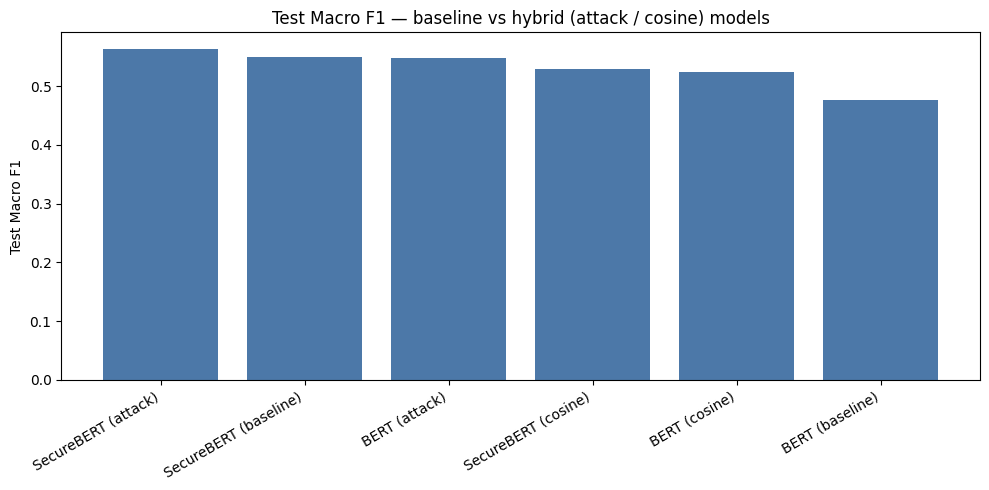


BEST OVERALL MODEL (by test macro F1)
Model:            SecureBERT
Candidate:        attack
Test Accuracy:    0.7048
Test Macro F1:    0.5633
Test Weighted F1: 0.7053


In [ ]:
# Combining the saved baseline results with the newly evaluated hybrid results
combined_rows = []

# Adding the baseline model results to the comparison
for model_name, metrics in baseline_results.items():
    combined_rows.append({
        "model": model_name,
        "candidate": "baseline",
        "test_accuracy": metrics["accuracy"],
        "test_macro_f1": metrics["macro_f1"],
        "test_weighted_f1": metrics["weighted_f1"],
        "test_macro_precision": metrics["macro_precision"],
        "test_macro_recall": metrics["macro_recall"],
    })

# Adding the hybrid model results to the comparison
combined_rows.extend(final_results)

# Creating and sort the complete comparison table by test macro F1
combined_df = pd.DataFrame(combined_rows).sort_values(
    "test_macro_f1", ascending=False
).reset_index(drop=True)

# Printing the complete baseline vs hybrid model comparison
print("=== Full comparison: baseline vs attack-hybrid vs cosine-hybrid (TEST set) ===")
print(combined_df.to_string(index=False))

# Plotting test macro F1 scores for all model and candidate combinations
plt.figure(figsize=(10, 5))
labels_for_plot = combined_df["model"] + " (" + combined_df["candidate"] + ")"
plt.bar(labels_for_plot, combined_df["test_macro_f1"], color="#4C78A8")
plt.ylabel("Test Macro F1")
plt.title("Test Macro F1 — baseline vs hybrid (attack / cosine) models")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Identifying the best overall model based on test macro F1
best_row = combined_df.iloc[0]

# Printing the performance of the best overall model
print("\n" + "=" * 60)
print("BEST OVERALL MODEL (by test macro F1)")
print("=" * 60)
print(f"Model: {best_row['model']}")
print(f"Candidate: {best_row['candidate']}")
print(f"Test Accuracy: {best_row['test_accuracy']:.4f}")
print(f"Test Macro F1: {best_row['test_macro_f1']:.4f}")
print(f"Test Weighted F1:{best_row['test_weighted_f1']:.4f}")

In [ ]:
# Saving the hybrid-only results and the full combined comparison to Drive
HYBRID_SAVE_DIR = os.path.join(DRIVE_DIR, "hybrid_scores")
os.makedirs(HYBRID_SAVE_DIR, exist_ok=True)

final_results_df.to_json(os.path.join(HYBRID_SAVE_DIR, "hybrid_results.json"), orient="records", indent=2)
combined_df.to_json(os.path.join(HYBRID_SAVE_DIR, "combined_comparison.json"), orient="records", indent=2)

print("Saved hybrid results and full combined comparison to:")
print(HYBRID_SAVE_DIR)
print(os.listdir(HYBRID_SAVE_DIR))


Saved hybrid results and full combined comparison to:
/content/drive/MyDrive/apt_extraction/hybrid_scores
['hybrid_results.json', 'combined_comparison.json']
